In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported succesfully!")

Libraries imported succesfully!


In [2]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.shape

(1000, 9)

In [4]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [6]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [9]:
print("Mean Total Amount =", df["Total Amount"].mean())
print("Median Total Amount =", df["Total Amount"].median())
print("Mode Total Amount =", df["Total Amount"].mode())
print("Standard Deviation=", df["Total Amount"].std())

Mean Total Amount = 456.0
Median Total Amount = 135.0
Mode Total Amount = 0    50
Name: Total Amount, dtype: int64
Standard Deviation= 559.997631555123


In [10]:
df["Gender"].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

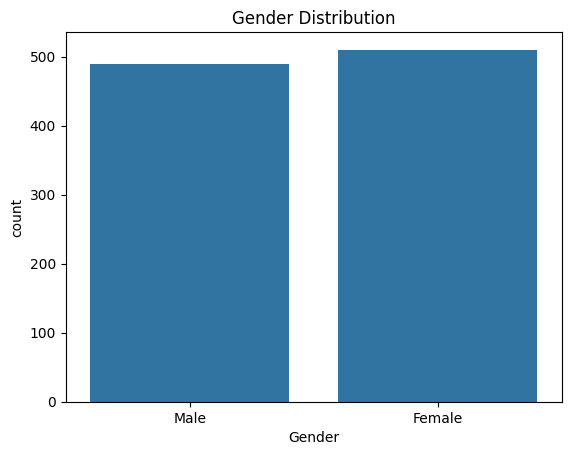

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

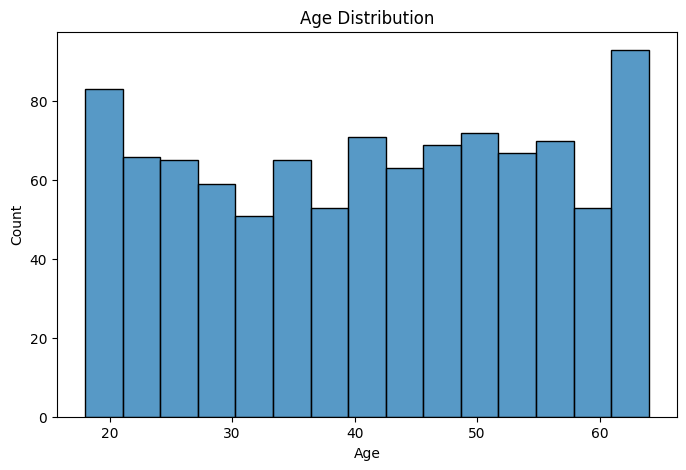

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=15)
plt.title("Age Distribution")
plt.show()

In [14]:
df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [15]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()
category_sales

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

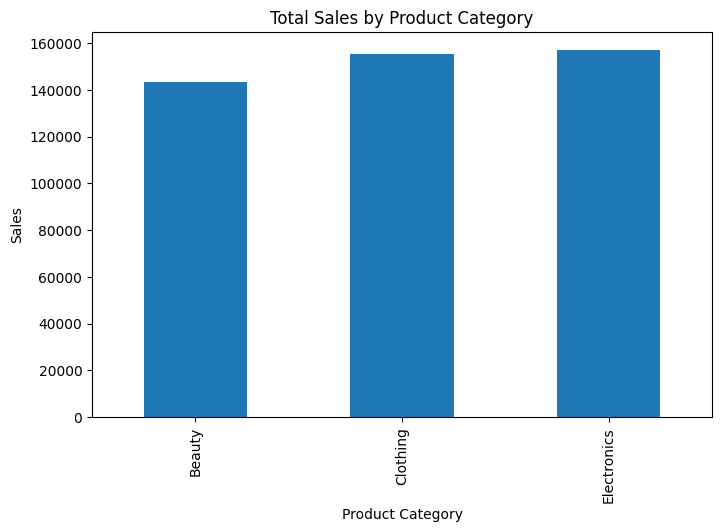

In [16]:
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Product Category")
plt.ylabel("Sales")
plt.show()

In [17]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()
gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

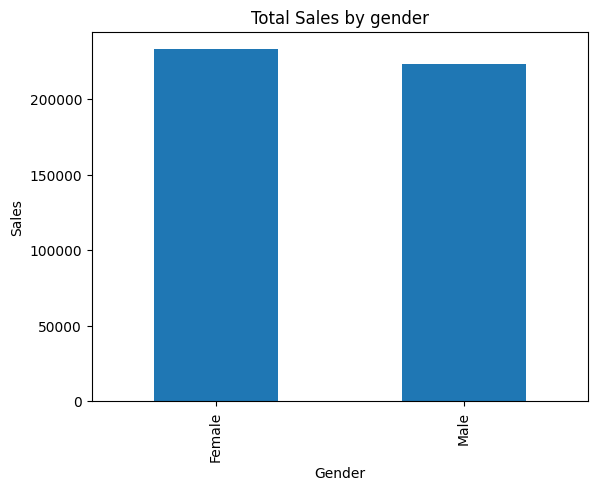

In [18]:
gender_sales.plot(kind="bar")
plt.title("Total Sales by gender")
plt.ylabel("Sales")
plt.show()

In [19]:
df["Date"] = pd.to_datetime(df["Date"])

In [20]:
df["Month"] = df["Date"].dt.month
df[["Date", "Month"]].head()

,Date,Month
0,2023-11-24,11
1,2023-02-27,2
2,2023-01-13,1
3,2023-05-21,5
4,2023-05-06,5


In [21]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()
monthly_sales

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

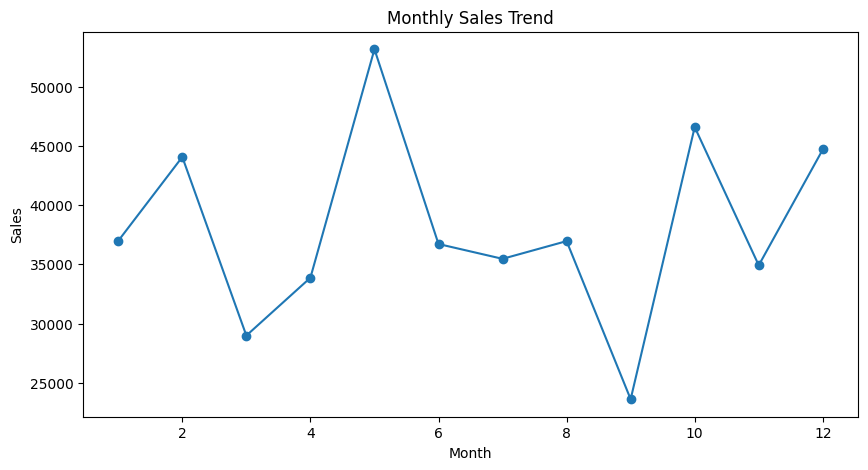

In [22]:
plt.figure(figsize=(10,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

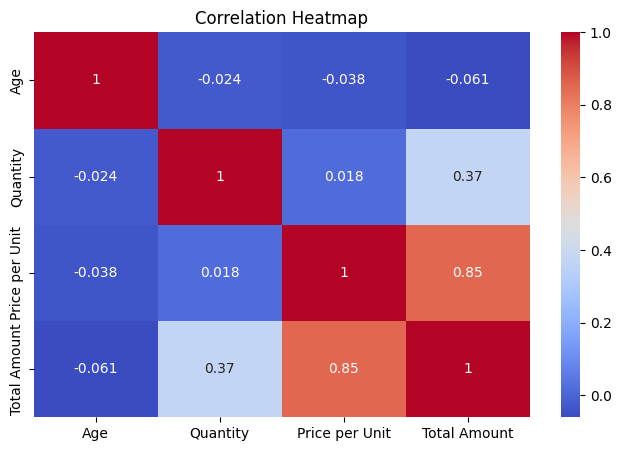

In [23]:
plt.figure(figsize=(8,5))
sns.heatmap(df[["Age","Quantity","Price per Unit","Total Amount"]].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [26]:
df.groupby("Age")["Total Amount"].sum().sort_values(ascending=False).head(10)

Age
43    17970
34    16785
51    16065
19    14870
26    13980
22    13700
46    13090
21    12585
47    12505
37    11650
Name: Total Amount, dtype: int64

In [27]:
top_customers = df.groupby("Customer ID")["Total Amount"].sum()
top_customers.sort_values(ascending=False).head(10)

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
Name: Total Amount, dtype: int64

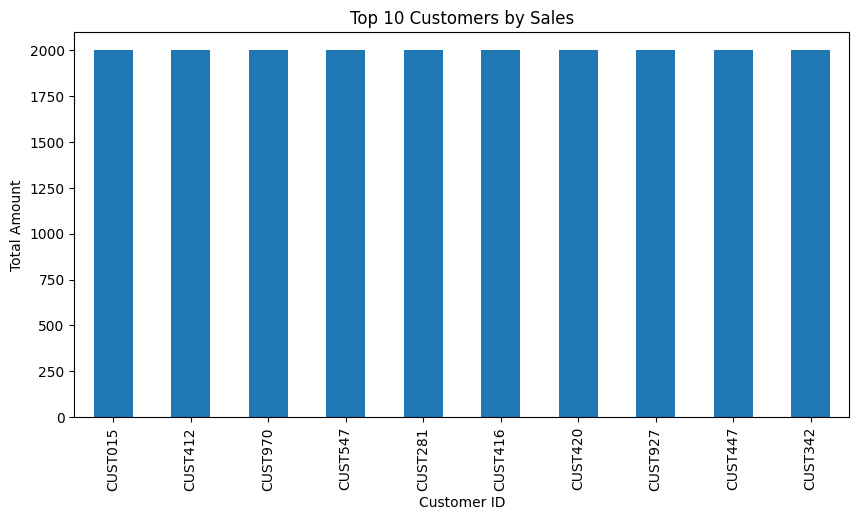

In [28]:
plt.figure(figsize=(10,5))
top_customers.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Customers by Sales")
plt.ylabel("Total Amount")
plt.show()

In [29]:
df["Customer ID"].nunique()

1000

In [30]:
df["Customer ID"].count()

np.int64(1000)

In [31]:
df["Total Amount"].max()

np.int64(2000)

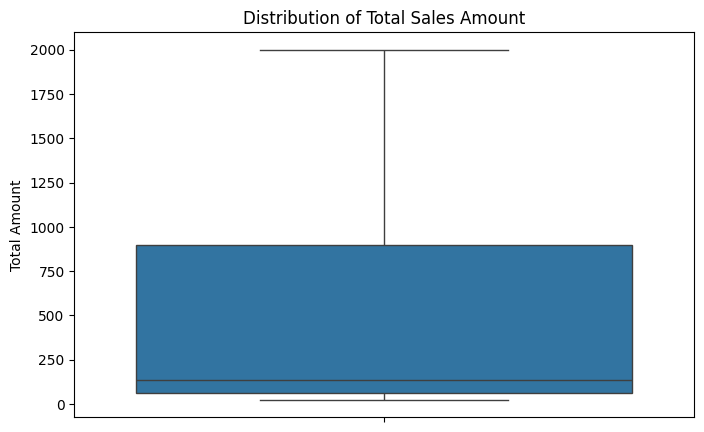

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Total Amount"])
plt.title("Distribution of Total Sales Amount")
plt.show()

In [33]:
df.groupby("Month")["Quantity"].sum()

Month
1     199
2     214
3     194
4     214
5     259
6     197
7     176
8     227
9     170
10    252
11    205
12    207
Name: Quantity, dtype: int64

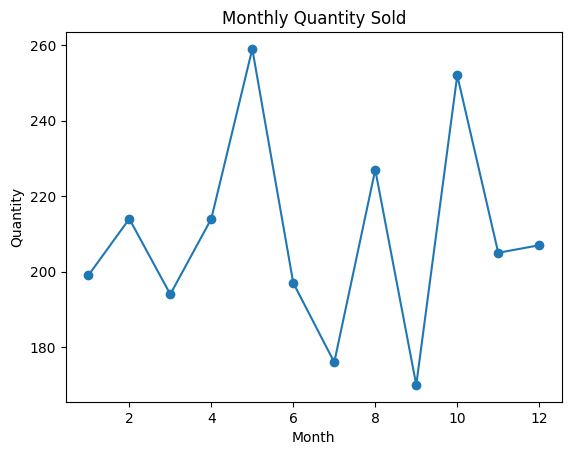

In [34]:
monthly_quantity = df.groupby("Month")["Quantity"].sum()
monthly_quantity.plot(marker="o")
plt.title("Monthly Quantity Sold")
plt.ylabel("Quantity")
plt.show()

In [35]:
df.duplicated().sum()

np.int64(0)

# Results and Findings

## Dataset Overview

* The dataset contains 1000 transactions and 1000 unique customers.
* No missing values or duplicate records were found.
* The dataset was clean and suitable for analysis.

## Descriptive Statistics

* Mean Transaction Amount: ₹456
* Median Transaction Amount: ₹135
* Mode Transaction Amount: ₹50
* Standard Deviation: ₹559.99

The mean transaction amount is significantly higher than the median, indicating the presence of high-value transactions and a positively skewed distribution.

## Customer Demographics Analysis

* Female Customers: 510
* Male Customers: 490

The customer base is nearly balanced, with female customers slightly outnumbering male customers.

## Product Category Analysis

* Clothing: 351 transactions
* Electronics: 342 transactions
* Beauty: 307 transactions

Revenue Generated:

* Electronics: ₹156,905
* Clothing: ₹155,580
* Beauty: ₹143,515

Electronics generated the highest revenue among all product categories.

## Customer Purchasing Behavior

* The highest spending age groups were 43, 34, and 51 years.
* Female customers contributed slightly more revenue than male customers.

## Sales Trend Analysis

Monthly sales showed fluctuations throughout the year, indicating seasonal variations in customer purchasing behavior.

## Correlation Analysis

The heatmap revealed relationships among Age, Quantity, Price per Unit, and Total Amount. Correlation analysis was performed only on numerical variables because categorical variables such as Gender and Product Category cannot be meaningfully correlated.


# Recommendations

1. Increase inventory and promotional efforts for Electronics products since they generate the highest revenue.

2. Develop targeted marketing campaigns for female customers, who contribute a slightly larger share of sales.

3. Analyze peak sales months and replicate successful strategies during low-performing months.

4. Introduce customer loyalty programs to encourage repeat purchases and improve customer retention.

5. Focus on high-value transactions and premium products to maximize revenue generation.

6. Use customer demographic insights to create personalized marketing campaigns for different age groups.

7. Continuously monitor sales trends and customer behavior to support data-driven business decisions.


# Conclusion

This project performed Exploratory Data Analysis (EDA) on a retail sales dataset to identify customer behavior patterns, product performance, and sales trends. The analysis revealed that Electronics was the highest revenue-generating category, female customers contributed slightly more sales revenue, and customer spending exhibited a positively skewed distribution. Monthly sales trends indicated fluctuations in purchasing activity throughout the year. The insights and recommendations derived from this analysis can help businesses improve inventory management, marketing effectiveness, customer engagement, and overall decision-making.
